In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/employee_salary_dataset.csv')

In [3]:
df.head()

,EmployeeID,Name,Department,Experience_Years,Education_Level,Age,Gender,City,Monthly_Salary
0,1,Employee_1,Marketing,15,Master,53,Female,Delhi,111416
1,2,Employee_2,Operations,7,Bachelor,25,Female,Bangalore,95271
2,3,Employee_3,IT,12,High School,51,Female,Hyderabad,69064
3,4,Employee_4,Operations,8,PhD,44,Male,Delhi,95091
4,5,Employee_5,Operations,15,Master,36,Female,Delhi,132450


In [4]:
df = df.drop(columns='EmployeeID',axis=1)

In [5]:
df.head()

,Name,Department,Experience_Years,Education_Level,Age,Gender,City,Monthly_Salary
0,Employee_1,Marketing,15,Master,53,Female,Delhi,111416
1,Employee_2,Operations,7,Bachelor,25,Female,Bangalore,95271
2,Employee_3,IT,12,High School,51,Female,Hyderabad,69064
3,Employee_4,Operations,8,PhD,44,Male,Delhi,95091
4,Employee_5,Operations,15,Master,36,Female,Delhi,132450


In [6]:
df.tail()

,Name,Department,Experience_Years,Education_Level,Age,Gender,City,Monthly_Salary
45,Employee_46,HR,3,PhD,54,Female,Hyderabad,88208
46,Employee_47,Finance,3,Master,22,Female,Delhi,58828
47,Employee_48,Operations,1,High School,40,Male,Chennai,43711
48,Employee_49,Finance,5,PhD,23,Female,Hyderabad,28420
49,Employee_50,Marketing,10,High School,47,Female,Bangalore,121752


In [7]:
df.shape

(50, 8)

In [8]:
df.isnull().sum()

,0
Name,0
Department,0
Experience_Years,0
Education_Level,0
Age,0
Gender,0
City,0
Monthly_Salary,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Name              50 non-null     object
 1   Department        50 non-null     object
 2   Experience_Years  50 non-null     int64 
 3   Education_Level   50 non-null     object
 4   Age               50 non-null     int64 
 5   Gender            50 non-null     object
 6   City              50 non-null     object
 7   Monthly_Salary    50 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 3.3+ KB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['City'].value_counts()

,count
City,
Delhi,15
Hyderabad,12
Bangalore,11
Mumbai,7
Chennai,5


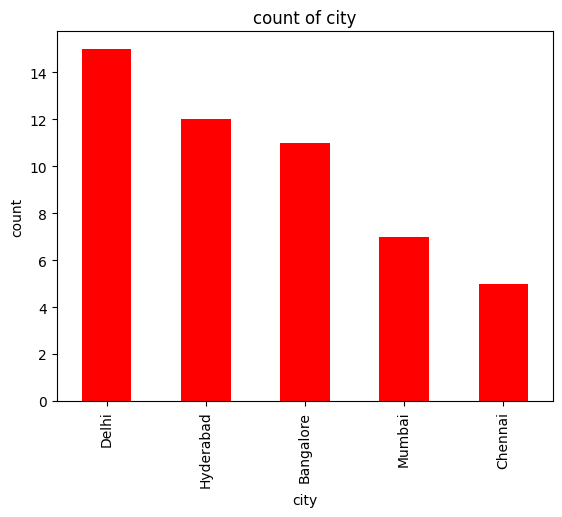

In [12]:
df['City'].value_counts().plot(kind='bar',color='red')
plt.title('count of city')
plt.xlabel('city')
plt.ylabel('count')
plt.show()

In [13]:
df['Department'].value_counts()

,count
Department,
Marketing,13
Operations,10
IT,10
Finance,10
HR,7


<Axes: ylabel='count'>

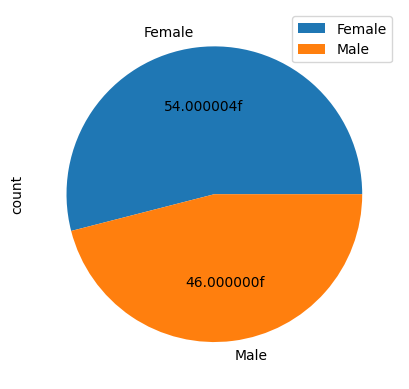

In [14]:
df['Gender'].value_counts()
print('\n')
df['Gender'].value_counts().plot(kind='pie',legend=True,autopct='%1ff')

In [15]:
df['Education_Level'].value_counts()

,count
Education_Level,
Master,19
High School,12
PhD,10
Bachelor,9


Pre-processing

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Feature Selection

In [18]:
X = df.drop(columns=['Name', 'Monthly_Salary'])
y = df['Monthly_Salary']

In [19]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

Train the Model

In [21]:
model = LinearRegression()

In [22]:
model.fit(X_train,y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

In [25]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [26]:
print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Mean Squared Error: 922226357.1708435
R-squared Score: 0.2178175126566455


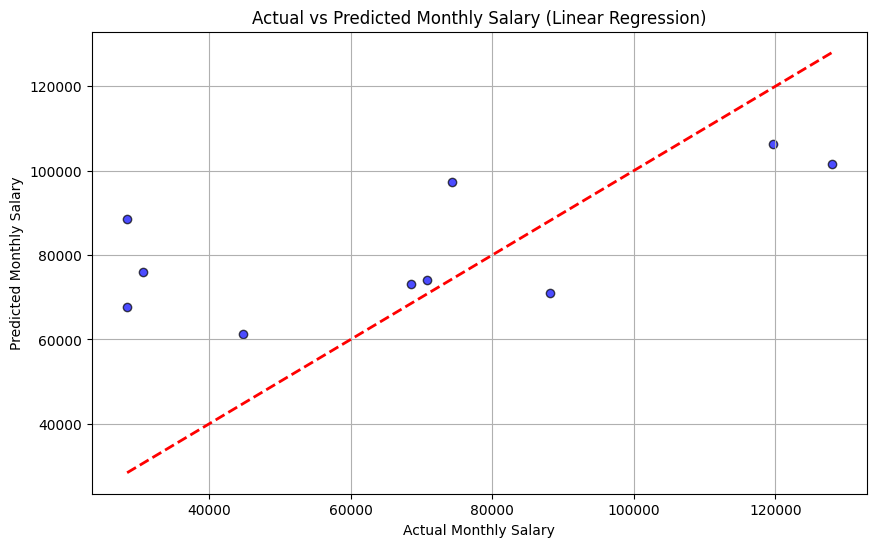

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolors='k', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Monthly Salary')
plt.ylabel('Predicted Monthly Salary')
plt.title('Actual vs Predicted Monthly Salary (Linear Regression)')
plt.grid(True)

In [28]:
coefficients = pd.DataFrame({'Feature': X_encoded.columns, 'Coefficient': model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print("\nFeature Coefficients:")
print(coefficients)


Feature Coefficients:
                        Feature   Coefficient
4          Department_Marketing  16274.814704
3                 Department_IT  12209.623936
5         Department_Operations  10410.679682
2                 Department_HR  10221.278021
11                   City_Delhi   1786.801093
7        Education_Level_Master    982.180217
0              Experience_Years   -149.755252
1                           Age   -229.806366
8           Education_Level_PhD  -2742.843859
6   Education_Level_High School  -3591.785482
9                   Gender_Male  -5967.777435
13                  City_Mumbai -16031.261408
12               City_Hyderabad -23324.619239
10                 City_Chennai -32744.618566
